In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
def mostrar(img, titulo="", cmap="gray", figsize=(12,4)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

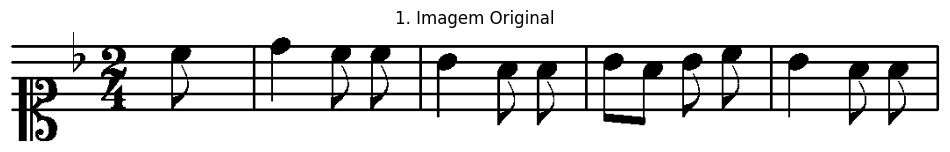

In [3]:
caminho_imagem = "partitura.png"
pasta_destino = "output_simbolos"

if not os.path.exists(pasta_destino):
    os.makedirs(pasta_destino)

    # =========================================================
    # 1. CARREGAR IMAGEM
    # =========================================================
img = cv2.imread(caminho_imagem, 0)

if img is None:
    print("Erro ao carregar imagem")

mostrar(img, "1. Imagem Original")


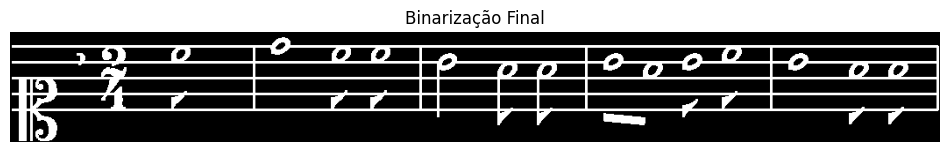

In [4]:
# contraste
clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8,8)
)

img2 = clahe.apply(img)

# blur
blur = cv2.GaussianBlur(img2, (1,1), 0)

# threshold adaptativo
binary = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    19,
    10
)

# limpeza
kernel = np.ones((3,3), np.uint8)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

mostrar(binary, "Binarização Final")

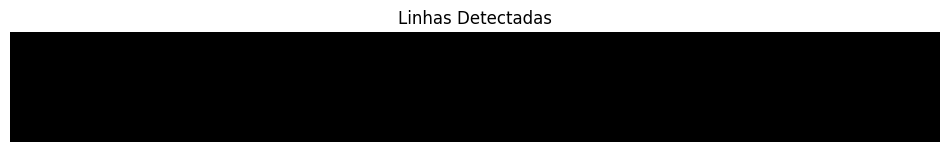

Quantidade de linhas: 0


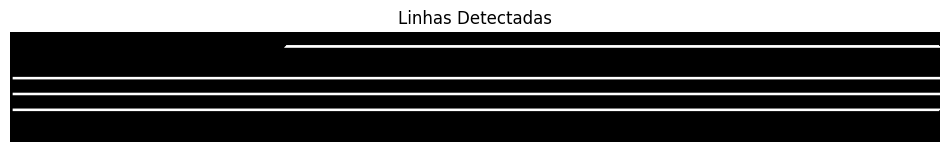

Quantidade de linhas: 4


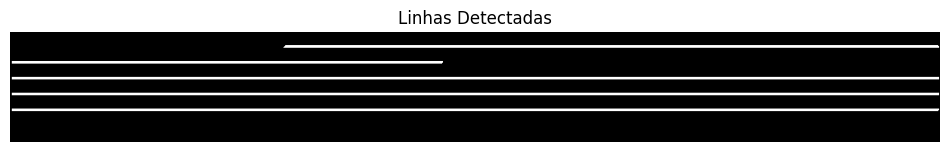

Quantidade de linhas: 5


In [5]:
# =========================================================
# DETECTAR LINHAS HORIZONTAIS
# =========================================================

altura, largura = binary.shape

quantidade_linhas = 0
num = 1
while quantidade_linhas < 5:

    kernel_horizontal = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (largura // num, 1)
    )

    num += 1

    linhas = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel_horizontal
    )


    mostrar(linhas, "Linhas Detectadas")

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        linhas,
        connectivity=8
    )

    # Remove o fundo
    quantidade_linhas = num_labels - 1

    print("Quantidade de linhas:", quantidade_linhas)

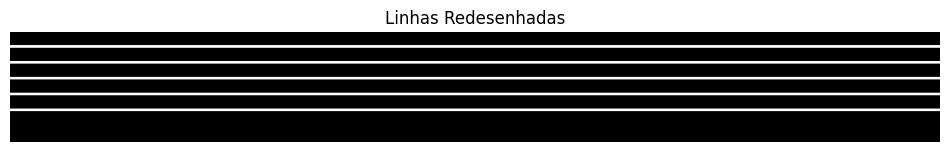

In [6]:
altura, largura = linhas.shape

projecao = np.sum(linhas > 0, axis=1)

limiar = largura * 0.1
ys = np.where(projecao > limiar)[0]

linhas_redesenhadas = np.zeros_like(linhas)

# Agrupar linhas consecutivas
grupos = []
if len(ys):
    inicio = ys[0]

    for i in range(1, len(ys)):
        if ys[i] - ys[i - 1] > 1:
            grupos.append((inicio, ys[i - 1]))
            inicio = ys[i]

    grupos.append((inicio, ys[-1]))

# Redesenhar cada faixa horizontal
for y1, y2 in grupos:
    linhas_redesenhadas[y1:y2 + 1, :] = 255

mostrar(linhas_redesenhadas, "Linhas Redesenhadas")



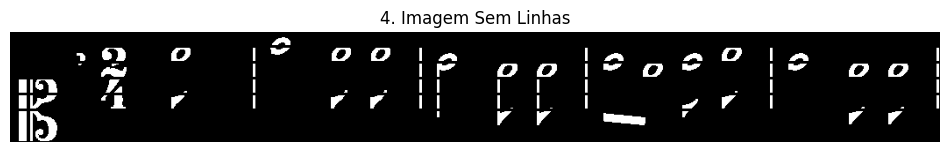

In [7]:
 # =========================================================
    # 4. REMOVER LINHAS
    # =========================================================
linhas_completas = cv2.erode(
    linhas_redesenhadas,
    cv2.getStructuringElement(cv2.MORPH_RECT, (3,1)),
    iterations=1
)

sem_linhas = cv2.subtract(binary, linhas_completas)

mostrar(sem_linhas, "4. Imagem Sem Linhas")


In [8]:

# =========================================================
# RECONSTRUIR SÍMBOLOS HORIZONTAIS
# =========================================================

#kernel_reconstrucao = cv2.getStructuringElement(
#    cv2.MORPH_RECT,
#    (15,1)
#)

#sem_linhas = cv2.dilate(
#    sem_linhas,
#    kernel_reconstrucao,
#    iterations=1
#)

# afina novamente
#sem_linhas = cv2.erode(
#    sem_linhas,
#    kernel_reconstrucao,
#    iterations=1
#)

#mostrar(sem_linhas, "4. Imagem Sem Linhas")

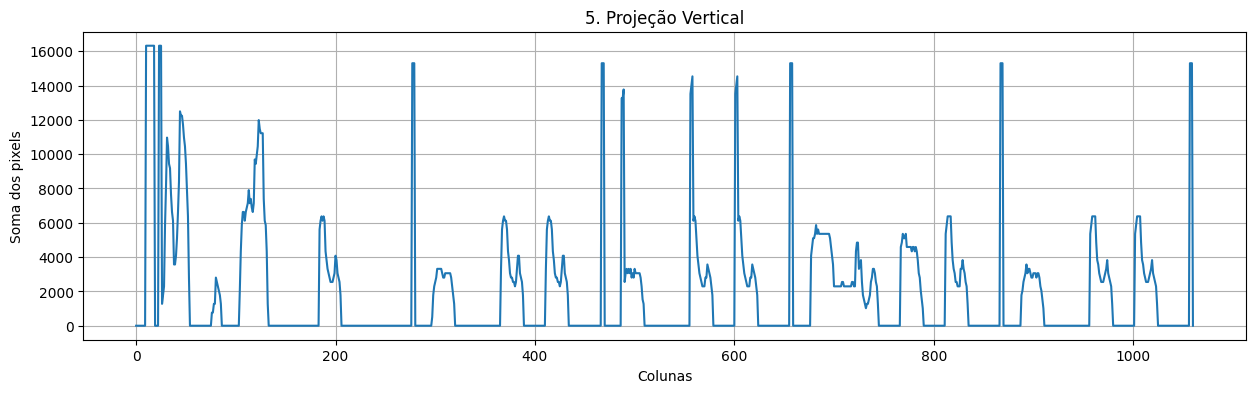

In [9]:
# =========================================================
# 5. PROJEÇÃO VERTICAL
# =========================================================
projecao = np.sum(sem_linhas, axis=0)

plt.figure(figsize=(15,4))
plt.plot(projecao)
plt.title("5. Projeção Vertical")
plt.xlabel("Colunas")
plt.ylabel("Soma dos pixels")
plt.grid()
plt.show()

21 símbolos encontrados


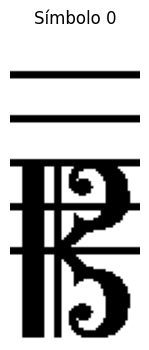

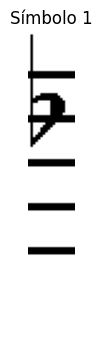

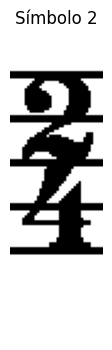

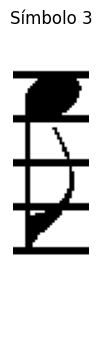

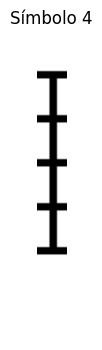

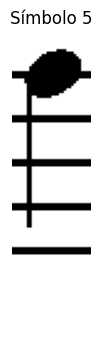

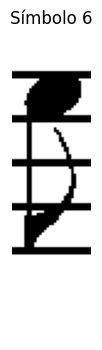

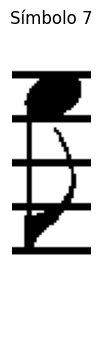

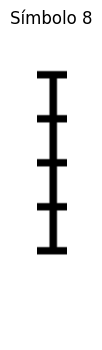

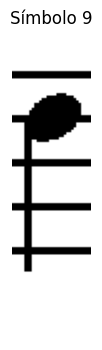

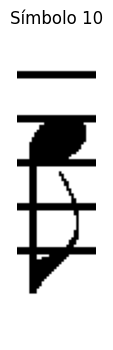

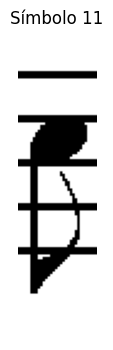

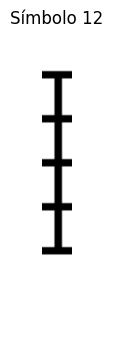

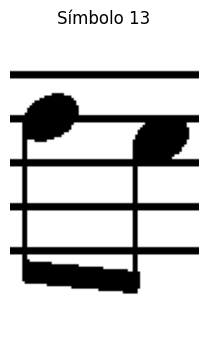

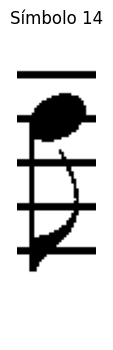

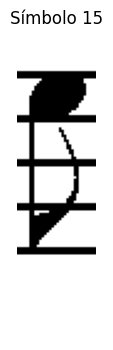

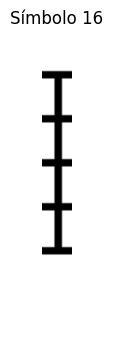

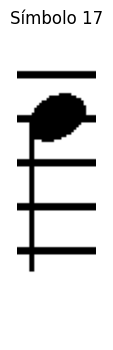

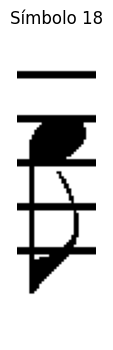

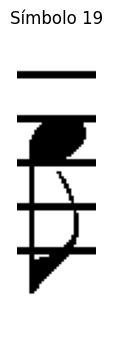

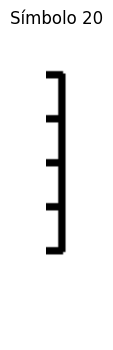

In [10]:
# =========================================================
# 6. EXTRAÇÃO DOS SÍMBOLOS
# =========================================================
simbolos = []

em_simbolo = False
inicio = 0

espaco_max_vazio = 7
contador_vazio = 0

for x, valor in enumerate(projecao):

        if valor > 500:

            if not em_simbolo:
                inicio = x
                em_simbolo = True

            contador_vazio = 0

        elif valor <= 500 and em_simbolo:

            contador_vazio += 1

            if contador_vazio > espaco_max_vazio:

                fim = x - contador_vazio

                recorte = img[
                    :,
                    max(0, inicio-5):min(img.shape[1], fim+5)
                ]

                simbolos.append(recorte)

                em_simbolo = False
                contador_vazio = 0


# Último símbolo
if em_simbolo:

        fim = len(projecao) - contador_vazio

        recorte = img[
            :,
            max(0, inicio-5):min(img.shape[1], fim+5)
        ]

        simbolos.append(recorte)


    # =========================================================
    # 7. MOSTRAR SÍMBOLOS
    # =========================================================
print(f"{len(simbolos)} símbolos encontrados")

for i, s in enumerate(simbolos):

        mostrar(s, f"Símbolo {i}")

        cv2.imwrite(
            os.path.join(
                pasta_destino,
                f"simbolo_{i:03d}.png"
            ),
            s
        )


